<a href="https://colab.research.google.com/github/SelvaTharsan/Wholesale-Customers-Decision-Tree-Classifier/blob/main/Decision_Tree_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTRODUCTION
I have used the Wholesale Customers Dataset from the UCI Machine Learning Repository, which includes annual spending data for customers across six product categories: Fresh, Milk, Grocery, Frozen, Detergents_Paper, and Delicassen. The goal was to classify customers based on the Channel feature, distinguishing between HORECA (Hotel/Restaurant/Cafe) and Retail.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In here, I have imported the pandas and numpy libraries for my project to efficiently handle, manipulate, and analyze the dataset — pandas for structured data operations such as loading, filtering, and summarizing the data, and numpy for performing numerical computations and working with arrays.


In [ ]:
# Load dataset
df = pd.read_csv("Wholesale customers data.csv")

# Preview data
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In here i have used pandas library to Load my dataset Wholesale customers data.

df.head()-Retrieves the first five rows of data from the Wholesale Customers dataset.


In [ ]:
# Check for nulls
print(df.isnull().sum())
# Summary statistics
df.describe()


Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


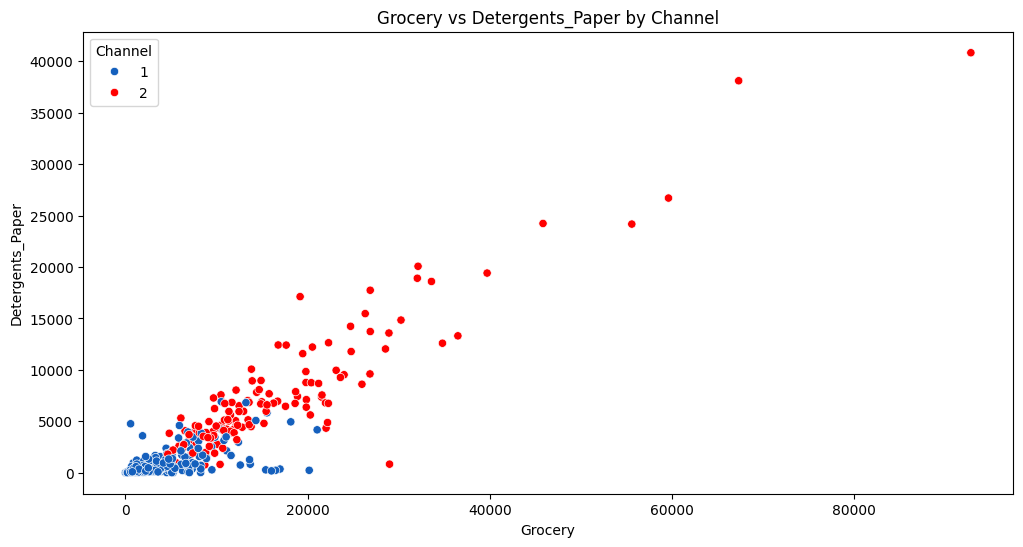

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='Grocery',
    y='Detergents_Paper',
    hue='Channel',
    data=df,
    palette=['#1560BD', 'red']
)
plt.title('Grocery vs Detergents_Paper by Channel')
plt.show()


This scatter plot revealed that customers in the Retail channel (Channel 2) generally had higher spending on
both Grocery and Detergents_Paper than those in Horeca (Channel 1). This visual clustering indicated that
these features are strong differentiators for classification.

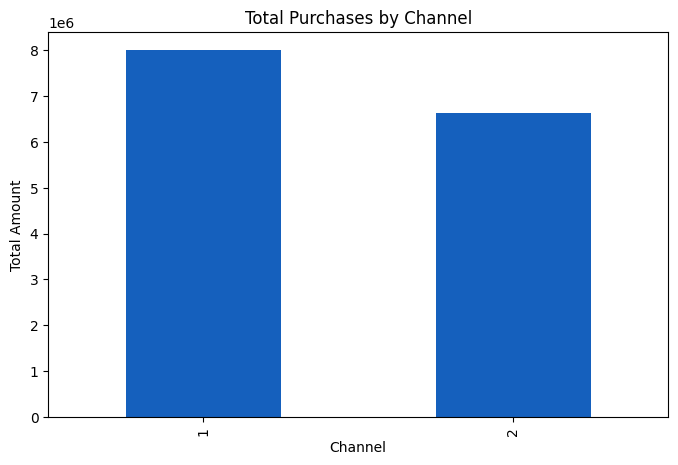

In [ ]:
product_categories = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
channel_totals = df.groupby('Channel')[product_categories].sum().sum(axis=1)
plt.figure(figsize=(8, 5))
channel_totals.plot(kind='bar', color='#1560BD')  # denim blue
plt.title('Total Purchases by Channel')
plt.ylabel('Total Amount')
plt.show()


Aggregation with Pandas & NumPy:
product_categories = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Then, using Pandas’ groupby combined with NumPy operations, calculated overall spending per channel:
channel_totals = df.groupby('Channel')[product_categories].sum().sum(axis=1)
This step leveraged Pandas for grouping and aggregation while NumPy’s underlying fast array operations
computed sums and means efficiently.

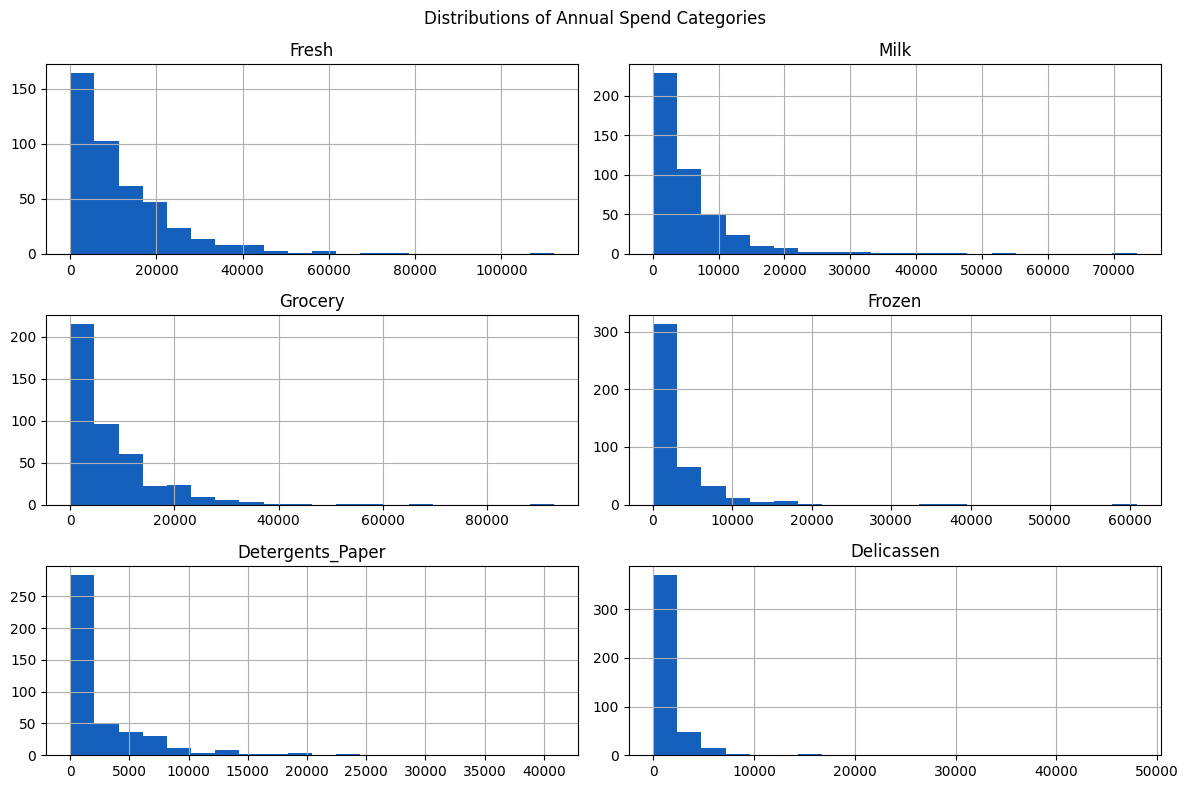

In [ ]:
df.drop(['Channel', 'Region'], axis=1).hist(figsize=(12, 8), bins=20, color='#1560BD')
plt.suptitle('Distributions of Annual Spend Categories')
plt.tight_layout()
plt.show()

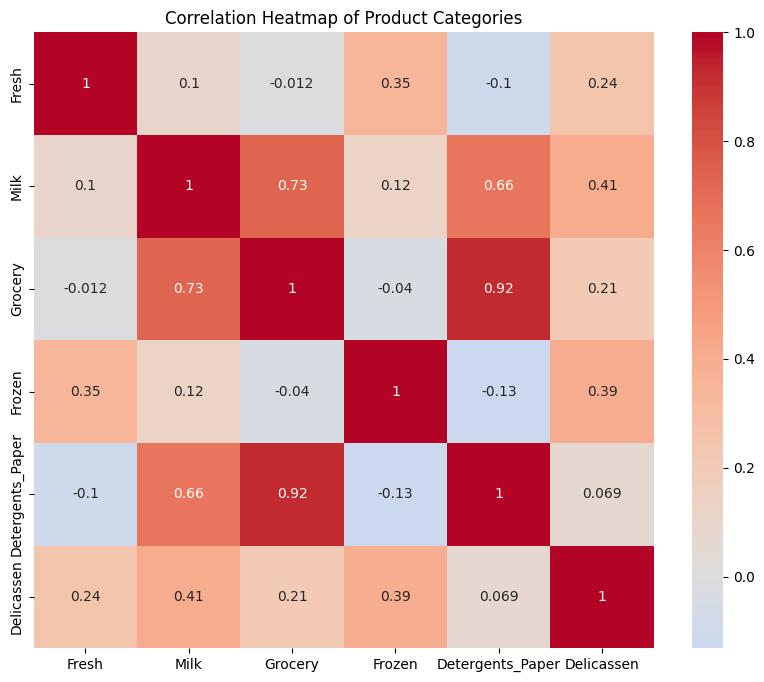

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[product_categories].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Product Categories')
plt.show()

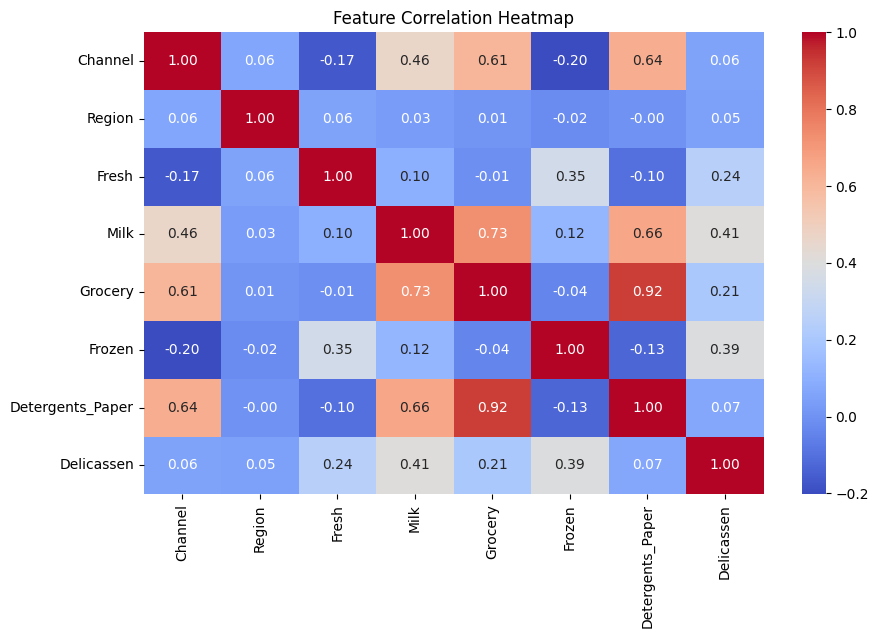

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

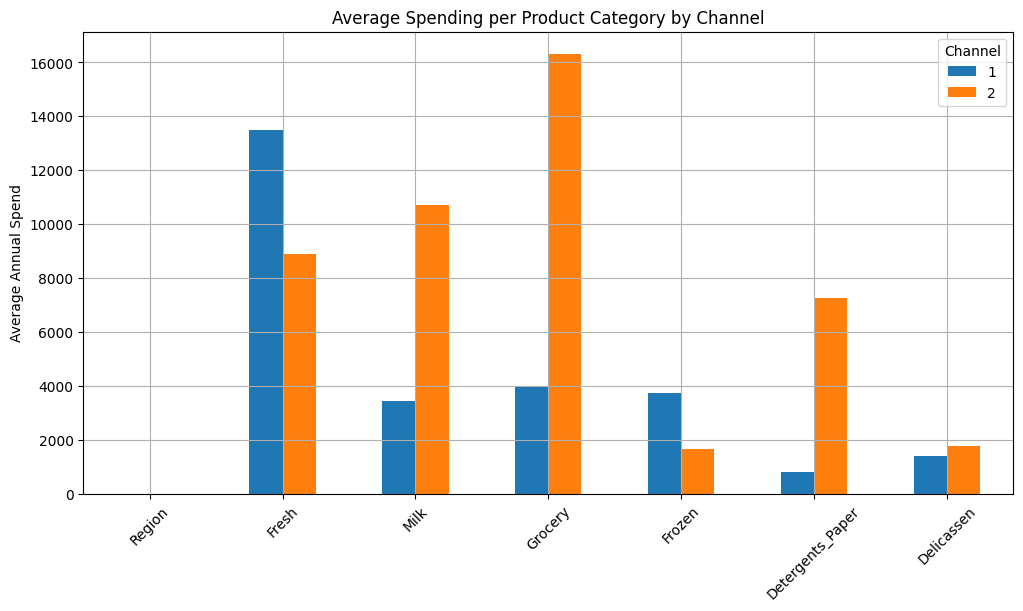

In [ ]:
channel_mean = df.groupby('Channel').mean()

channel_mean.T.plot(kind='bar', figsize=(12, 6))
plt.title("Average Spending per Product Category by Channel")
plt.ylabel("Average Annual Spend")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

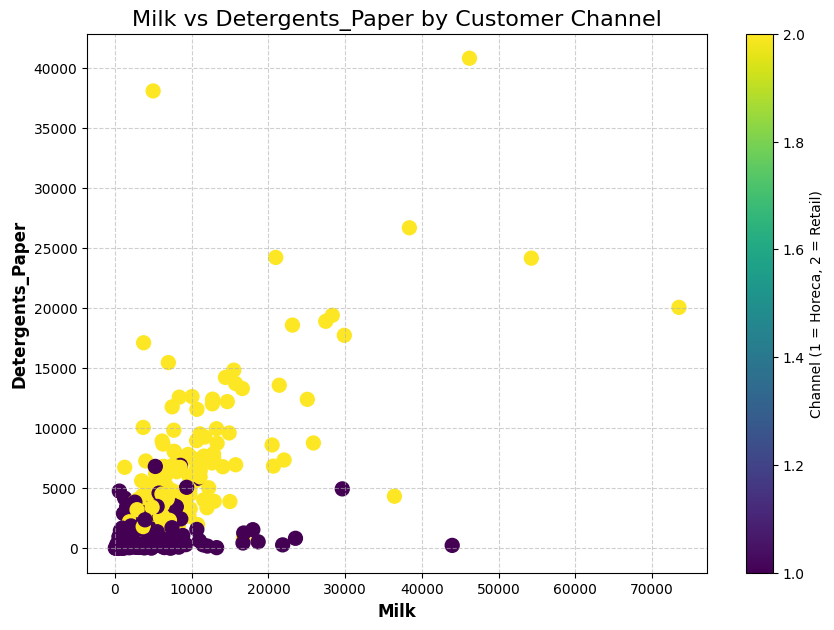

In [ ]:
# Choose two actual features to visualize
x_feature = 'Milk'
y_feature = 'Detergents_Paper'

# Create scatter plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df[x_feature],df[y_feature],c=df['Channel'],cmap='viridis',s=100,alpha=1)  # fully opaque

plt.colorbar(scatter, label="Channel (1 = Horeca, 2 = Retail)")
plt.title(f"{x_feature} vs {y_feature} by Customer Channel", fontsize=16)
plt.xlabel(x_feature, fontsize=12, fontweight='bold')
plt.ylabel(y_feature, fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

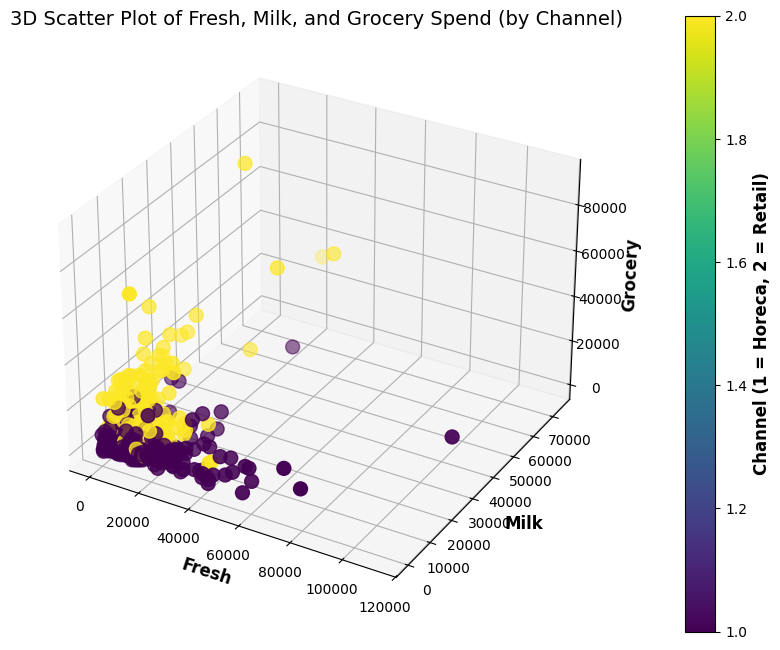

In [ ]:
# Select features
X = df[['Fresh', 'Milk', 'Grocery']]
labels = df['Channel']

#3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X['Fresh'], X['Milk'], X['Grocery'],c=labels,cmap='viridis',s=100)

ax.set_title("3D Scatter Plot of Fresh, Milk, and Grocery Spend (by Channel)", fontsize=14)
ax.set_xlabel("Fresh", fontsize=12, fontweight='bold')
ax.set_ylabel("Milk", fontsize=12, fontweight='bold')
ax.set_zlabel("Grocery", fontsize=12, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Channel (1 = Horeca, 2 = Retail)", fontsize=12, fontweight='bold')

ax.grid(True)
plt.show()

I used Seaborn and Matplotlib for clear, high-quality data visualizations.A scatter plot (Grocery vs.
Detergents_Paper) color-coded by channel revealed spending behavior differences. Histograms were used
to visualize the distribution of each product category, showing skewed spending patterns. Correlation
heatmaps highlighted strong relationships (e.g., between Grocery and Detergents_Paper). Bar plots
displayed total and average spending by channel across categories. 3D scatter plots helped explore patterns
across three features simultaneously.
These tools helped visually distinguish Horeca vs. Retail customers effectively.

The visual findings directly guided the feature selection for the Decision Tree.
Strongly correlated and channel-distinctive features like Grocery, Detergents_Paper, and Milk were
prioritized.Features with unclear patterns or wide overlap (like Region) were excluded from the model.The
decision to use only product spending data was reinforced by heatmap and 3D scatter patterns.These
insights improved the model’s accuracy and interpretability.
The model structure later validated these choices by splitting first on key features observed in the visuals.
Thus, visual analysis and model building were closely connected and mutually supportive.


In [ ]:
#features and target
X = df.drop(['Channel'], axis=1)
y = df['Channel']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Train the model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

Accuracy: 0.8409090909090909

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.86      0.89        65
           2       0.67      0.78      0.72        23

    accuracy                           0.84        88
   macro avg       0.79      0.82      0.80        88
weighted avg       0.85      0.84      0.84        88



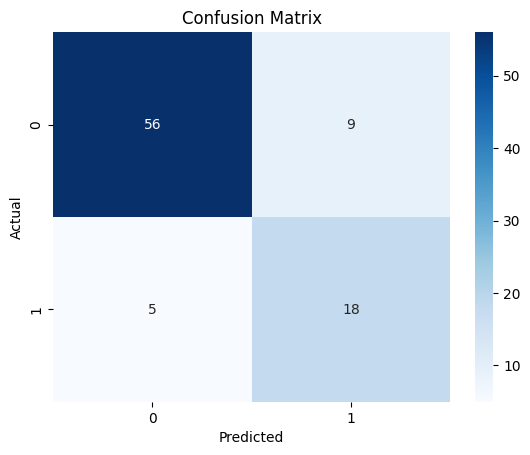

In [ ]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

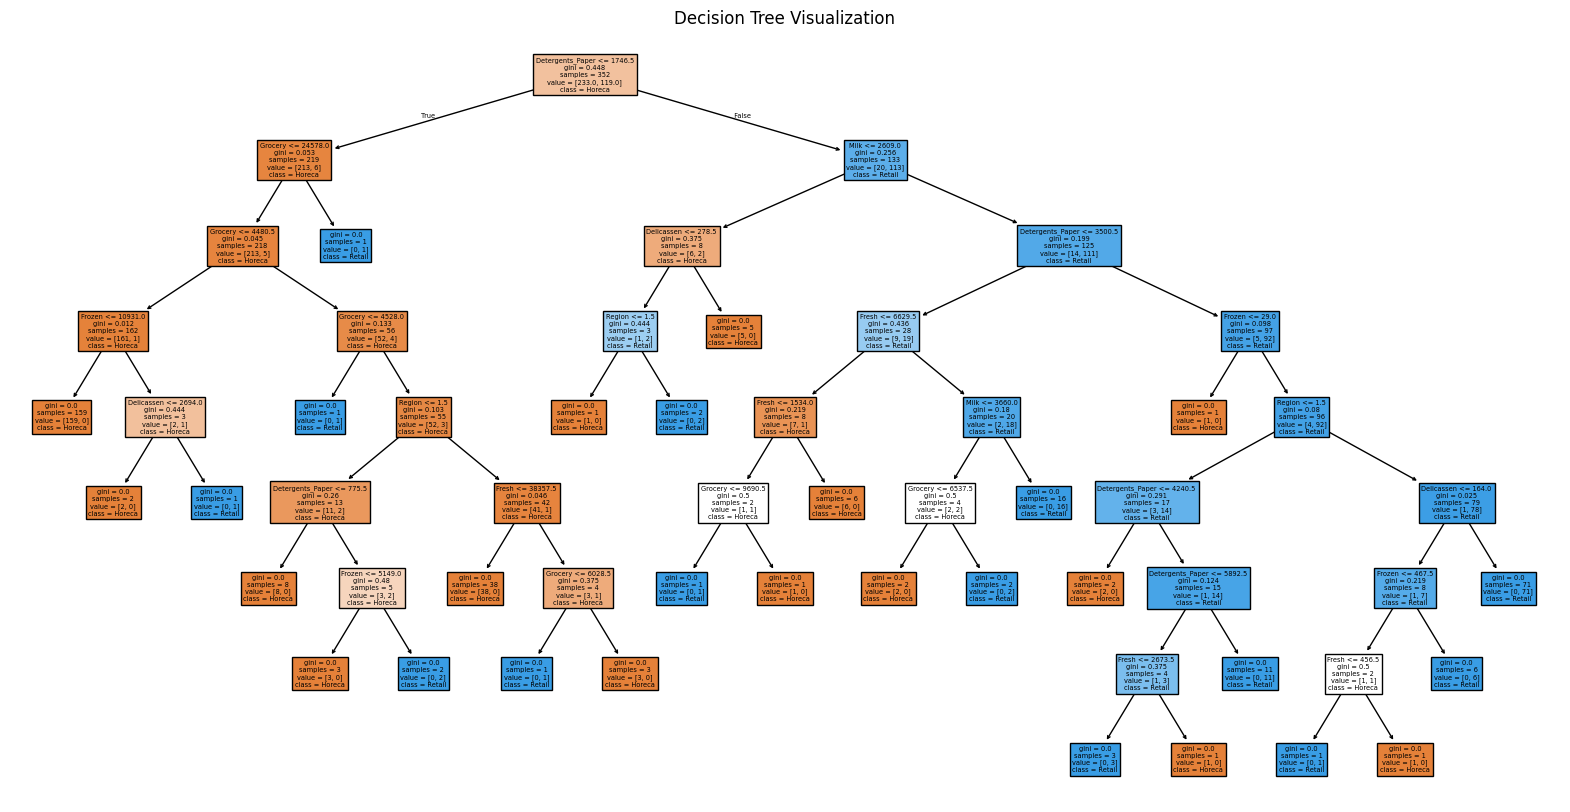

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['Horeca', 'Retail'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

The Decision Tree model highlighted Grocery, Detergents_Paper, and Milk as the most influential
features.Retail customers were often classified based on higher values in these spending categories.The
model achieved a strong accuracy of 84%, indicating reliable performance on test data.Precision and recall
scores were especially high for Horeca customers (Channel 1).The confusion matrix showed very few
misclassifications between the two customer types.These results confirm the patterns seen earlier in
scatterplotsandheatmaps. The model’s behavior matched well with the visual insights from the exploratory
analysis.

The Decision Tree breaks down classification into clear, interpretable decision paths. Each node represents
a rule based on a customer’s spending in a specific category. For example, “If Detergents_Paper > 2000
likely Retail” becomes a model decision rule. This makes the model not only accurate but also easy to
explain to non-technical users. The visualization of the tree reveals which features are most important for
classification. It helps us understand how different types of customers behave based on spending. Overall,
the tree links data patterns to business insights in a very transparent way